In [2]:

import tensorflow as tf
from tensorflow.keras import layers, models, Input
import numpy as np

In [3]:
data_train = np.load('train_set.npz')
X_train = data_train['X_train']
y_train = data_train['y_train']
data_test = np.load('test_set.npz')
X_test = data_test['X_test']
y_test = data_test['y_test']
data_val = np.load('val_set.npz')
X_val = data_val['X_val']
y_val = data_val['y_val']

In [4]:
def build_seizure_model(input_shape):
    model = models.Sequential([
        # Yeni Standart: Giriş katmanını ayrı bir Input objesi olarak tanımlıyoruz
        Input(shape=input_shape),

        # 1. Katman
        layers.Conv1D(filters=32, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 2. Katman
        layers.Conv1D(filters=64, kernel_size=3, activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 3. Katman
        layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
        layers.GlobalAveragePooling1D(),

        # Sınıflandırma
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),

        # Çıkış (Binary Classification)
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
    )

    return model

In [5]:
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_seizure_model(input_shape)

In [6]:
model.summary()

 Non-trainable params: 192 (768.00 B)

In [7]:
# Modelin takılıp kalmasını önlemek için Callback'ler
callbacks = [
    # 5 epoch boyunca gelişme olmazsa öğrenme oranını düşür (LR Annealing)
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001),

    # Val_loss artık düşmüyorsa eğitimi durdur (Zaman tasarrufu)
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

396/396 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9860 - loss: 0.0401 - precision: 0.9820 - recall: 0.9637 - val_accuracy: 0.8773 - val_loss: 0.5793 - val_precision: 0.9252 - val_recall: 0.6058 - learning_rate: 5.0000e-04


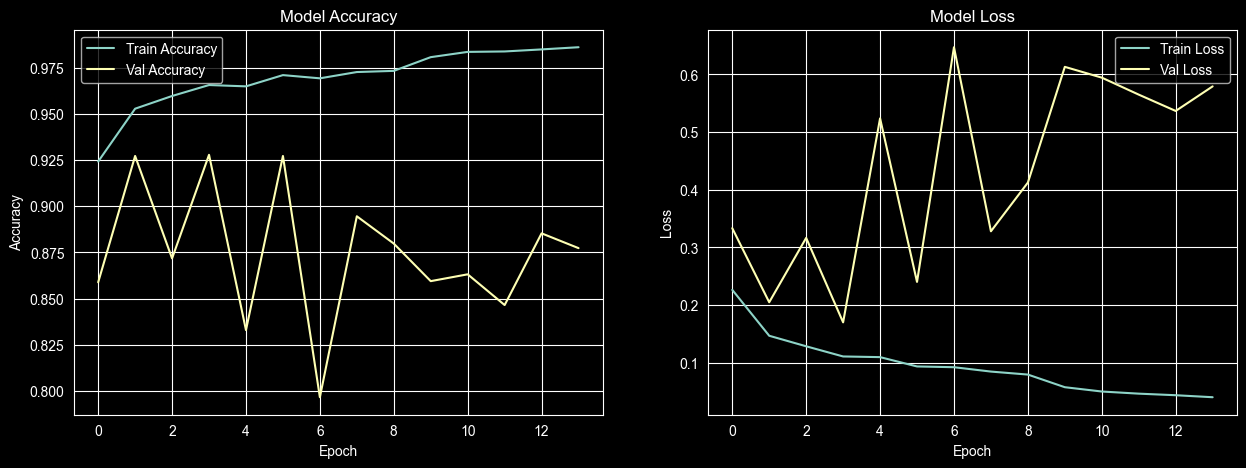

In [8]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Grafiği
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss Grafiği
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_history(history)

In [9]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Test seti üzerinde tahmin yap
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # 0.5 eşik değerine göre sınıfla

# Matrisi hesapla
cm = confusion_matrix(y_test, y_pred)

# Görselleştir
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Seizure'],
            yticklabels=['Normal', 'Seizure'])
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Detaylı Rapor (Precision, Recall, F1-Score)
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Seizure']))


📋 Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.93      0.94      5890
     Seizure       0.43      0.58      0.50       572

    accuracy                           0.90      6462
   macro avg       0.70      0.75      0.72      6462
weighted avg       0.91      0.90      0.90      6462



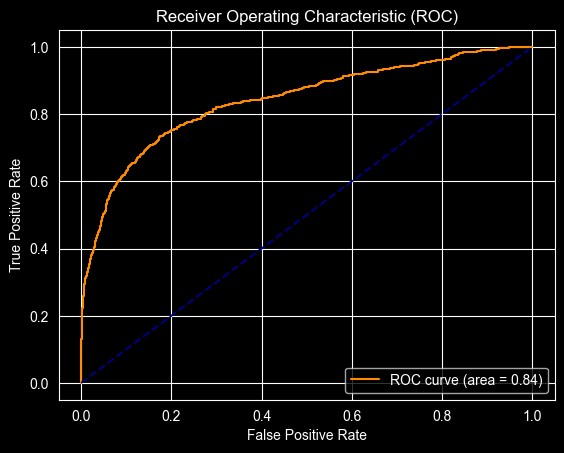

In [10]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()